In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Verificando os dados**

In [4]:
df = pd.read_excel("/content/Vendas - Ecommerce.xlsx")

# Avalia a estrutura dos dados coletados nas operações de venda
df.info()
print("\nNúmero de linhas com valor nulo:")
print(df.isnull().sum())

# Identifica possíveis falhas de processamento que inflam artificialmente o faturamento reportado
print("Número de linhas duplicadas:", df.duplicated().sum())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID da Venda          185 non-null    int64         
 1   Data da Venda        185 non-null    datetime64[ns]
 2   ID Produto           185 non-null    int64         
 3   Produto e Categoria  185 non-null    object        
 4   Quantidade           185 non-null    int64         
 5   Preço Unitário       185 non-null    float64       
 6   -                    0 non-null      float64       
 7   Preço Total          185 non-null    float64       
 8   Método de Pagamento  185 non-null    object        
 9   Canal                185 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 14.6+ KB

Número de linhas com valor nulo:
ID da Venda              0
Data da Venda            0
ID Produto               0
Produto e Cate

,ID da Venda,Data da Venda,ID Produto,Produto e Categoria,Quantidade,Preço Unitário,-,Preço Total,Método de Pagamento,Canal
0,1,2023-07-01 08:30:49,101,"Guarda-roupa,Móveis",5,249.27,NaN,1246.35,PIX,Website
1,2,2023-06-02 11:59:00,102,"Livro de História,Livros",9,590.11,NaN,5310.99,CARTÃO DE CRÉDITO,Website
2,3,2023-07-30 09:18:29,103,"Calça Jeans,Roupas",4,120.26,NaN,481.04,PIX,Website
3,4,2023-05-10 06:09:06,104,"Quebra-cabeça,Brinquedos",10,599.06,NaN,5990.60,CARTÃO DE CRÉDITO,Website
4,5,2023-08-11 00:01:14,105,"Livro de Receitas,Livros",3,600.94,NaN,1802.82,PIX,Website


# **Limpeza e Tratamento dos dados**

In [6]:
#Removendo a coluna nula
df.dropna(axis=1, inplace=True)

# Padronização de termos
df.columns = [
    "id_venda",
    "data_venda",
    "id_produto",
    "produto_categoria",
    "quantidade",
    "preco_unitario",
    "preco_total",
    "metodo_pagamento",
    "canal"
]

In [8]:
df["data_venda"] = pd.to_datetime(df["data_venda"])

# Criando novas colunas para armazenar os dados de colunas que possuiam duas ou mais informações
# Engenharia de Recursos: Isolando variáveis de tempo para identificar padrões de
# sazonalidade (ex: melhores dias da semana ou meses para campanhas de marketing)
df["ano"] = df["data_venda"].dt.year
df["mes"] = df["data_venda"].dt.month
df["dia"] = df["data_venda"].dt.day

df["produto"] = df["produto_categoria"].str.split(',').str[0]
df["categoria"] = df["produto_categoria"].str.split(',').str[1]

In [9]:
# Removendo as colunas antigas
df.drop("produto_categoria", axis=1, inplace=True)
df.drop("data_venda", axis=1, inplace=True)

In [10]:
# Mudando os tipos de dados de algumas colunas
df["metodo_pagamento"] = df["metodo_pagamento"].astype(str)
df["canal"] = df["canal"].astype(str)
df["produto"] = df["produto"].astype(str)
df["categoria"] = df["categoria"].astype(str)

# **Análise Exploratória (EDA)**

Quantidade de vendas por categoria:
      categoria  quantidade
0       Roupas         169
1   Brinquedos         196
2       Móveis         201
3       Livros         216
4  Eletrônicos         237
Quantidade de vendas por produto:
                   produto  quantidade
0                 Cadeira          10
1           Blusa de Frio          18
2                Carrinho          20
3                  Shorts          33
4                 Pelúcia          35
5                Camiseta          35
6           Quebra-cabeça          37
7              Smartphone          37
8                Notebook          38
9             Calça Jeans          39
10                   Mesa          39
11        Livro de Ficção          41
12      Jogo de Tabuleiro          41
13      Livro de Receitas          43
14      Livro de História          43
15                  Mangá          43
16                Vestido          44
17                   Sofá          45
18  Revista em Quadrinhos          46
19    

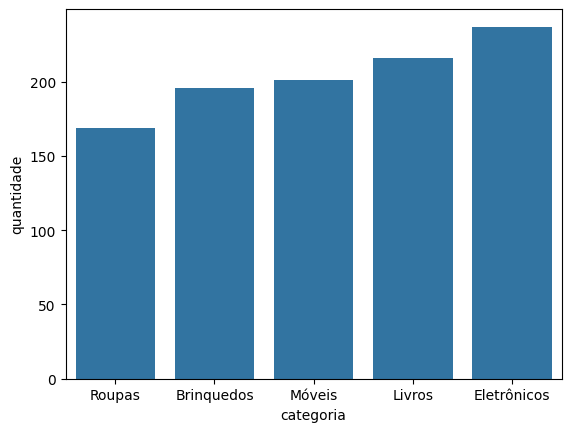

In [15]:
# Listando as categarias e produtos por quantidade de venda
#Identifica quais macrosegmentos trazem mais volume e
# sustentam a operação do e-commerce
categoria_vendas = df.groupby("categoria")["quantidade"].sum().sort_values().reset_index()

# Visão micro do estoque: Quais SKUs (produtos individuais) giram mais rápido
produtos_vendas = df.groupby("produto")["quantidade"].sum().sort_values().reset_index()
top_10_produtos = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False).head(10).reset_index()
print("Quantidade de vendas por categoria:\n", categoria_vendas)
print("Quantidade de vendas por produto:\n", produtos_vendas)

# Gráfico da quantidade de venda por categoria
# Permite ao gestor comercial entender onde investir mais verba de marketing (categorias líderes)
# ou onde aplicar estratégias de queima de estoque (categorias lanternas)
sns.barplot(
    x="categoria",
    y="quantidade",
    data=categoria_vendas
)

plt.show()

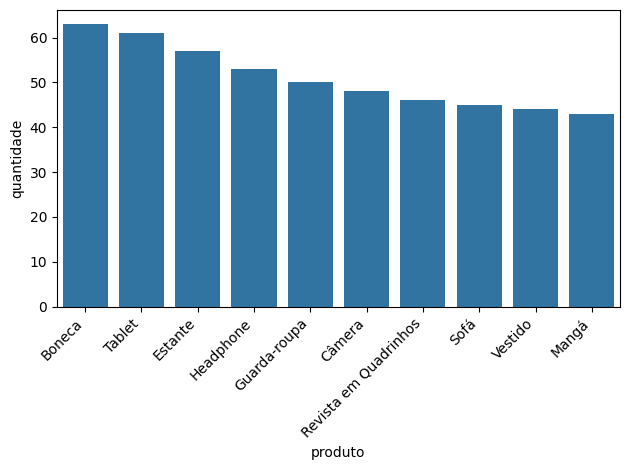

In [12]:
# Gráfico da quantidade de venda por produto
# Os Campeões de Vendas (Top 10)
# Direciona o foco do time de compras para negociações de volume com fornecedores desses itens específicos
sns.barplot(
    x="produto",
    y="quantidade",
    data=top_10_produtos
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Identificando as vendas de cada categoria por mês
# Sazonalidade Comercial: Revela o comportamento do consumidor ao longo do ano
# Útil para planejar estoque preventivo antes de picos de venda e campanhas (ex: Black Friday, Dia das Mães)
vendas_mensais = df.groupby(['categoria', 'mes'])['quantidade'].sum().unstack(fill_value=0)
print("Evolução mensal de vendas por categoria:")
print(vendas_mensais)

Evolução mensal de vendas por categoria:
mes           1   2   3   4   5   6   7   8
categoria                                  
Brinquedos   15   7  17  10  35  62  44   6
Eletrônicos  35  15  15  21  49  35  48  19
Livros       37  34  17  38  51  18   9  12
Móveis       47  31  13  25  23  15  31  16
Roupas       34  22  39  24  11   0  22  17


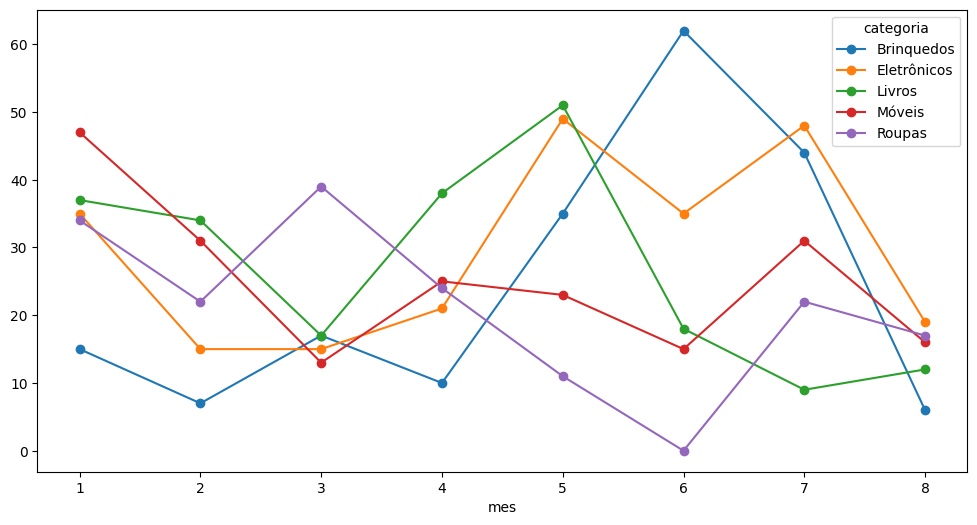

In [17]:
# Gráfico da quantidade de vendas das categorias por mês
# VISUALIZAÇÃO 3: Tendência de Mercado (Linha do Tempo)
# Facilita a identificação visual de categorias que estão crescendo mês a mês ou perdendo relevância no mercado
vendas_mensais.T.plot(kind="line", marker="o", figsize=(12, 6))
plt.show()